# Explainable Fraud Investigation Platform

## Model Development & Comparison

### Objective

This notebook develops and compares supervised machine learning models for fraud detection using the the saved outputs of `02_Data_Preprocessing_Feature_Engineering.ipynb`.

The comparison follows the MIA 5100 themes of parametric and non-parametric learning, decision trees, ensemble learning, stratified validation, hyperparameter tuning, and model evaluation. Because fraud is rare, **average precision (area under the precision-recall curve)** is the primary model-selection metric. ROC-AUC, recall, precision, F-scores, balanced accuracy, confusion matrices, also consideration of how many transactions the model flags for investigation.

### Deliverables

- Reproducible baselines and candidate models
- Validation comparison at the default 0.50 threshold
- Precision-recall and ROC curves
- Validation-only decision-threshold selection
- Optional cross-validated hyperparameter tuning
- One final, untouched test-set evaluation
- Persisted model, threshold, metrics, and transaction-level predictions

Validation set: used to compare models and choose the decision threshold—the probability above which a transaction is labelled fraudulent.
Test set: used only at the end to estimate how the finalized approach performs on unseen data.
“Decisions are frozen” which means that before examining test results, the following have already been chosen.
The winning model
Its hyperparameters
The decision threshold
The evaluation procedure

## 1. Import Libraries and Configure the Experiment

In [1]:
from pathlib import Path
from time import perf_counter
import json
import platform
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn import __version__ as sklearn_version
from sklearn.base import clone
from sklearn.calibration import CalibrationDisplay
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore", category=ConvergenceWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42
N_JOBS = -1

# Set True for a faster end-to-end rehearsal. Set False for final reported results.
QUICK_RUN = False
QUICK_TRAIN_ROWS = 120_000

# Optional, computationally heavier experiments.
RUN_MLP = True
RUN_TUNING = True
RUN_XGBOOST = True

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn_version}")
print(f"Quick run: {QUICK_RUN}")

Python: 3.11.15
pandas: 3.0.3
scikit-learn: 1.9.0
Quick run: False


### Design choices

- **Dummy classifier:** establishes the no-skill reference.
- **Logistic regression:** interpretable parametric baseline.
- **Decision tree:** non-parametric baseline with nonlinear interactions.
- **Random forest:** bagging ensemble that reduces tree variance.
- **Histogram gradient boosting:** efficient boosting model available in scikit-learn.
- **XGBoost:** external boosting benchmark.
- **Multi-layer perceptron:** neural-network comparison

Class weighting is learned from the training labels only. No synthetic observations are created, which avoids distorting already encoded transaction patterns. Resampling could be examined later as a controlled ablation.

## 2. Define Project Paths

In [2]:
def find_project_root(start=None):
    '''Find the repository from the notebook directory or current directory.'''
    candidates = [Path(start or Path.cwd()).resolve(), Path.cwd().resolve()]
    for candidate in candidates:
        for parent in [candidate, *candidate.parents]:
            if (parent / "data" / "processed").exists() and (parent / "notebooks").exists():
                return parent
    raise FileNotFoundError(
        "Could not locate the project root. Run this notebook from the repository "
        "or update PROJECT_ROOT manually."
    )


PROJECT_ROOT = find_project_root()
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"
MODEL_PATH = PROJECT_ROOT / "models" / "trained"
RESULTS_PATH = PROJECT_ROOT / "results" / "model_comparison"

MODEL_PATH.mkdir(parents=True, exist_ok=True)
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data: {PROCESSED_DATA_PATH}")
print(f"Models: {MODEL_PATH}")
print(f"Results: {RESULTS_PATH}")

Project root: /Users/hshazel/Projects/explainable-fraud-investigation-platform
Processed data: /Users/hshazel/Projects/explainable-fraud-investigation-platform/data/processed
Models: /Users/hshazel/Projects/explainable-fraud-investigation-platform/models/trained
Results: /Users/hshazel/Projects/explainable-fraud-investigation-platform/results/model_comparison


## 3. Load Training and Validation Data

In [3]:
required_files = [
    "X_train.parquet", "X_validation.parquet",
    "y_train.parquet", "y_validation.parquet",
    "id_train.parquet", "id_validation.parquet",
]
missing_files = [name for name in required_files if not (PROCESSED_DATA_PATH / name).exists()]
if missing_files:
    raise FileNotFoundError(
        "Run notebook 02 first. Missing processed files: " + ", ".join(missing_files)
    )

X_train = pd.read_parquet(PROCESSED_DATA_PATH / "X_train.parquet")
X_validation = pd.read_parquet(PROCESSED_DATA_PATH / "X_validation.parquet")
y_train = pd.read_parquet(PROCESSED_DATA_PATH / "y_train.parquet")["isFraud"].astype("int8")
y_validation = pd.read_parquet(PROCESSED_DATA_PATH / "y_validation.parquet")["isFraud"].astype("int8")
id_train = pd.read_parquet(PROCESSED_DATA_PATH / "id_train.parquet")["TransactionID"]
id_validation = pd.read_parquet(PROCESSED_DATA_PATH / "id_validation.parquet")["TransactionID"]

print(f"Training:   X={X_train.shape}, fraud rate={y_train.mean():.3%}")
print(f"Validation: X={X_validation.shape}, fraud rate={y_validation.mean():.3%}")

Training:   X=(413378, 324), fraud rate=3.499%
Validation: X=(88581, 324), fraud rate=3.500%


### 3.1 Data-contract integrity checks

In [4]:
assert len(X_train) == len(y_train) == len(id_train)
assert len(X_validation) == len(y_validation) == len(id_validation)
assert X_train.columns.equals(X_validation.columns)
assert X_train.columns.is_unique
assert set(y_train.unique()).issubset({0, 1})
assert set(y_validation.unique()).issubset({0, 1})
assert not id_train.isin(set(id_validation)).any()
assert not X_train.isna().to_numpy().any()
assert not X_validation.isna().to_numpy().any()
assert np.isfinite(X_train.to_numpy(dtype=np.float32)).all()
assert np.isfinite(X_validation.to_numpy(dtype=np.float32)).all()

data_contract = pd.DataFrame({
    "Split": ["Training", "Validation"],
    "Rows": [len(X_train), len(X_validation)],
    "Features": [X_train.shape[1], X_validation.shape[1]],
    "Fraud cases": [int(y_train.sum()), int(y_validation.sum())],
    "Fraud rate": [y_train.mean(), y_validation.mean()],
})
display(data_contract.style.format({"Fraud rate": "{:.3%}"}))
print("All integrity checks passed.")

,Split,Rows,Features,Fraud cases,Fraud rate
0,Training,413378,324,14464,3.499%
1,Validation,88581,324,3100,3.500%


All integrity checks passed.


### 3.2 Optional stratified quick-run sample

In [5]:
def stratified_subsample(X, y, ids, n_rows, random_state=RANDOM_STATE):
    if n_rows >= len(X):
        return X, y, ids
    rng = np.random.default_rng(random_state)
    selected = []
    for label in sorted(y.unique()):
        label_idx = np.flatnonzero(y.to_numpy() == label)
        take = round(n_rows * len(label_idx) / len(y))
        selected.extend(rng.choice(label_idx, size=take, replace=False))
    selected = np.array(selected)
    rng.shuffle(selected)
    return (
        X.iloc[selected].reset_index(drop=True),
        y.iloc[selected].reset_index(drop=True),
        ids.iloc[selected].reset_index(drop=True),
    )


if QUICK_RUN:
    X_fit, y_fit, id_fit = stratified_subsample(
        X_train, y_train, id_train, QUICK_TRAIN_ROWS
    )
else:
    X_fit, y_fit, id_fit = X_train, y_train, id_train

print(f"Fitting rows: {len(X_fit):,}")
print(f"Fitting fraud rate: {y_fit.mean():.3%}")

Fitting rows: 413,378
Fitting fraud rate: 3.499%


## 4. Define Evaluation Functions

In [6]:
def positive_class_probability(model, X):
    '''Return a continuous score with larger values meaning more likely fraud.'''
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return 1 / (1 + np.exp(-np.clip(scores, -500, 500)))
    raise TypeError(f"{type(model).__name__} does not expose probability-like scores.")


def metric_row(y_true, probability, threshold=0.50):
    prediction = (probability >= threshold).astype("int8")
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return {
        "Threshold": threshold,
        "ROC-AUC": roc_auc_score(y_true, probability),
        "Average precision": average_precision_score(y_true, probability),
        "Balanced accuracy": balanced_accuracy_score(y_true, prediction),
        "Precision": precision_score(y_true, prediction, zero_division=0),
        "Recall": recall_score(y_true, prediction, zero_division=0),
        "F1": f1_score(y_true, prediction, zero_division=0),
        "F2": fbeta_score(y_true, prediction, beta=2, zero_division=0),
        "Alerts": int(prediction.sum()),
        "Alert rate": float(prediction.mean()),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }


def threshold_table(y_true, probability):
    precision, recall, thresholds = precision_recall_curve(y_true, probability)
    table = pd.DataFrame({
        "Threshold": thresholds,
        "Precision": precision[:-1],
        "Recall": recall[:-1],
    })
    table["F1"] = (
        2 * table["Precision"] * table["Recall"] /
        (table["Precision"] + table["Recall"] + 1e-12)
    )
    table["F2"] = (
        5 * table["Precision"] * table["Recall"] /
        (4 * table["Precision"] + table["Recall"] + 1e-12)
    )
    sorted_probability = np.sort(np.asarray(probability))
    alert_counts = len(sorted_probability) - np.searchsorted(
        sorted_probability, thresholds, side="left"
    )
    table["Predicted alert rate"] = alert_counts / len(sorted_probability)
    return table


def plot_confusion(y_true, probability, threshold, title):
    prediction = (probability >= threshold).astype("int8")
    matrix = confusion_matrix(y_true, prediction, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(5.2, 4.3))
    sns.heatmap(matrix, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax)
    ax.set(xlabel="Predicted class", ylabel="Actual class", title=title)
    ax.set_xticklabels(["Legitimate", "Fraud"])
    ax.set_yticklabels(["Legitimate", "Fraud"], rotation=0)
    plt.tight_layout()
    return ax

### Metric interpretation

- **Average precision (primary):** summarizes the precision-recall trade-off and is informative under severe class imbalance.
- **ROC-AUC:** measures ranking discrimination but can look optimistic when negatives dominate.
- **Recall:** fraction of fraud cases detected; missed fraud appears as false negatives.
- **Precision:** fraction of alerts that are truly fraudulent; low precision increases investigator workload.
- **F2:** weights recall more than precision and is used here for threshold selection.
- **Balanced accuracy:** averages fraud and legitimate-class recall.

Accuracy is intentionally omitted from model ranking because predicting every transaction as legitimate would appear strong on this imbalanced dataset while detecting no fraud.

## 5. Define Candidate Models

In [7]:
models = {
    "Dummy (prior)": DummyClassifier(strategy="prior", random_state=RANDOM_STATE),
    "Logistic regression": LogisticRegression(
        class_weight="balanced", solver="saga", penalty="l2",
        C=1.0, max_iter=300, tol=1e-3, random_state=RANDOM_STATE,
    ),
    "Decision tree": DecisionTreeClassifier(
        class_weight="balanced", max_depth=12, min_samples_leaf=50,
        random_state=RANDOM_STATE,
    ),
    "Random forest": RandomForestClassifier(
        n_estimators=300 if not QUICK_RUN else 100,
        class_weight="balanced_subsample", max_depth=18,
        min_samples_leaf=5, max_features="sqrt", n_jobs=N_JOBS,
        random_state=RANDOM_STATE,
    ),
    "Histogram gradient boosting": HistGradientBoostingClassifier(
        learning_rate=0.08, max_iter=250 if not QUICK_RUN else 100,
        max_leaf_nodes=31, min_samples_leaf=30, l2_regularization=1.0,
        early_stopping=True, validation_fraction=0.10,
        random_state=RANDOM_STATE,
    ),
}

if RUN_MLP:
    models["Multi-layer perceptron"] = MLPClassifier(
        hidden_layer_sizes=(64, 32), activation="relu", alpha=1e-4,
        batch_size=1024, learning_rate_init=1e-3,
        max_iter=60, early_stopping=True, validation_fraction=0.10,
        n_iter_no_change=6, random_state=RANDOM_STATE,
    )

if RUN_XGBOOST:
    try:
        from xgboost import XGBClassifier
        negative, positive = np.bincount(y_fit)
        models["XGBoost"] = XGBClassifier(
            n_estimators=500 if not QUICK_RUN else 150,
            max_depth=6, learning_rate=0.05, subsample=0.8,
            colsample_bytree=0.8, min_child_weight=5,
            reg_lambda=1.0, scale_pos_weight=negative / positive,
            objective="binary:logistic", eval_metric="aucpr",
            tree_method="hist", n_jobs=N_JOBS, random_state=RANDOM_STATE,
        )
    except Exception as error:
        print(
            "XGBoost could not be loaded; continuing with scikit-learn models.\n"
            f"Reason: {type(error).__name__}: {error}"
        )

pd.DataFrame({"Candidate model": list(models)}).style.hide(axis="index")

Candidate model
Dummy (prior)
Logistic regression
Decision tree
Random forest
Histogram gradient boosting
Multi-layer perceptron
XGBoost


## 6. Train Models and Compare Validation Performance

In [8]:
fitted_models = {}
validation_probabilities = {}
comparison_rows = []

balanced_sample_weight = compute_sample_weight(class_weight="balanced", y=y_fit)

for name, estimator in models.items():
    print(f"Training {name} ...")
    model = clone(estimator)
    start = perf_counter()

    # HistGradientBoosting and MLP lack class_weight. HGB accepts sample_weight;
    # MLP is retained as an optional unweighted course comparison.
    if name == "Histogram gradient boosting":
        model.fit(X_fit, y_fit, sample_weight=balanced_sample_weight)
    else:
        model.fit(X_fit, y_fit)

    seconds = perf_counter() - start
    probability = positive_class_probability(model, X_validation)
    row = metric_row(y_validation, probability, threshold=0.50)
    row.update({"Model": name, "Fit seconds": seconds})

    fitted_models[name] = model
    validation_probabilities[name] = probability
    comparison_rows.append(row)
    print(
        f"  AP={row['Average precision']:.4f} | "
        f"ROC-AUC={row['ROC-AUC']:.4f} | {seconds:.1f}s"
    )

validation_results = (
    pd.DataFrame(comparison_rows)
    .set_index("Model")
    .sort_values("Average precision", ascending=False)
)

display(
    validation_results[[
        "Average precision", "ROC-AUC", "Balanced accuracy",
        "Precision", "Recall", "F1", "F2", "Alert rate", "Fit seconds",
    ]].style.format({
        "Average precision": "{:.4f}", "ROC-AUC": "{:.4f}",
        "Balanced accuracy": "{:.4f}", "Precision": "{:.4f}",
        "Recall": "{:.4f}", "F1": "{:.4f}", "F2": "{:.4f}",
        "Alert rate": "{:.2%}", "Fit seconds": "{:.1f}",
    }).background_gradient(subset=["Average precision"], cmap="YlGn")
)

Training Dummy (prior) ...
  AP=0.0350 | ROC-AUC=0.5000 | 0.0s
Training Logistic regression ...


/Users/hshazel/Projects/explainable-fraud-investigation-platform/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


  AP=0.0993 | ROC-AUC=0.7010 | 39.8s
Training Decision tree ...
  AP=0.4558 | ROC-AUC=0.8744 | 8.4s
Training Random forest ...
  AP=0.6407 | ROC-AUC=0.9300 | 45.7s
Training Histogram gradient boosting ...
  AP=0.6502 | ROC-AUC=0.9386 | 36.4s
Training Multi-layer perceptron ...
  AP=0.3104 | ROC-AUC=0.6719 | 10.9s
Training XGBoost ...
  AP=0.6851 | ROC-AUC=0.9465 | 15.3s


,Average precision,ROC-AUC,Balanced accuracy,Precision,Recall,F1,F2,Alert rate,Fit seconds
Model,,,,,,,,,
XGBoost,0.6851,0.9465,0.8721,0.2914,0.8161,0.4295,0.6000,9.80%,15.3
Histogram gradient boosting,0.6502,0.9386,0.8603,0.2449,0.8113,0.3762,0.5547,11.59%,36.4
Random forest,0.6407,0.9300,0.8246,0.4569,0.6784,0.5460,0.6184,5.20%,45.7
Decision tree,0.4558,0.8744,0.8092,0.1684,0.7532,0.2753,0.4445,15.65%,8.4
Multi-layer perceptron,0.3104,0.6719,0.6314,0.5854,0.2697,0.3693,0.3023,1.61%,10.9
Logistic regression,0.0993,0.7010,0.6326,0.0528,0.7594,0.0987,0.2065,50.34%,39.8
Dummy (prior),0.0350,0.5000,0.5000,0.0000,0.0000,0.0000,0.0000,0.00%,0.0


### 6.1 Precision-recall and ROC curves

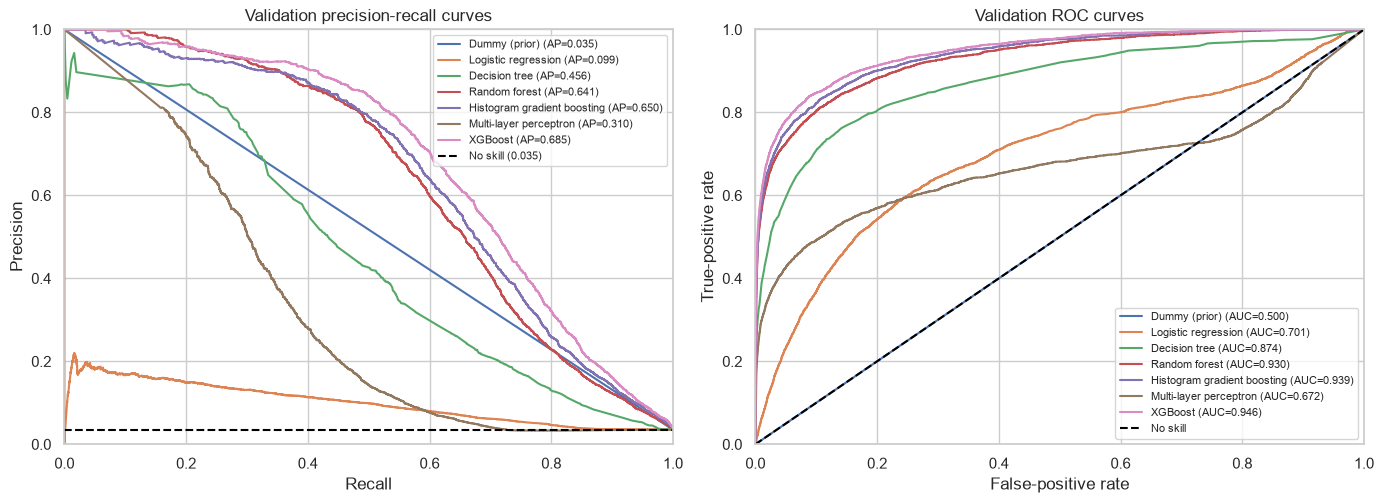

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
prevalence = y_validation.mean()

for name, probability in validation_probabilities.items():
    precision, recall, _ = precision_recall_curve(y_validation, probability)
    fpr, tpr, _ = roc_curve(y_validation, probability)
    ap = average_precision_score(y_validation, probability)
    auc = roc_auc_score(y_validation, probability)
    axes[0].plot(recall, precision, label=f"{name} (AP={ap:.3f})")
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

axes[0].axhline(prevalence, color="black", linestyle="--", label=f"No skill ({prevalence:.3f})")
axes[0].set(xlabel="Recall", ylabel="Precision", title="Validation precision-recall curves", xlim=(0, 1), ylim=(0, 1))
axes[1].plot([0, 1], [0, 1], color="black", linestyle="--", label="No skill")
axes[1].set(xlabel="False-positive rate", ylabel="True-positive rate", title="Validation ROC curves", xlim=(0, 1), ylim=(0, 1))
for ax in axes:
    ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

### 6.2 Select the champion by validation average precision

In [10]:
eligible_models = validation_results.drop(index="Dummy (prior)", errors="ignore")
champion_name = eligible_models["Average precision"].idxmax()
champion_model = fitted_models[champion_name]
champion_validation_probability = validation_probabilities[champion_name]

print(f"Champion model: {champion_name}")
print(f"Validation average precision: {eligible_models.loc[champion_name, 'Average precision']:.4f}")
print(f"Validation ROC-AUC: {eligible_models.loc[champion_name, 'ROC-AUC']:.4f}")

Champion model: XGBoost
Validation average precision: 0.6851
Validation ROC-AUC: 0.9465


## 7. Select an Operating Threshold on Validation Data

The best ranking model is not automatically the best operational classifier at a 0.50 cutoff. The threshold is selected **only on validation data**. This notebook uses maximum F2 as a recall-oriented default, while also reporting workload-constrained alternatives.

For deployment, the threshold should ultimately reflect the relative cost of missed fraud and unnecessary investigations, plus the investigation team's alert capacity.

In [11]:
thresholds = threshold_table(y_validation, champion_validation_probability)

f2_threshold = float(thresholds.loc[thresholds["F2"].idxmax(), "Threshold"])

# Useful operating points: highest recall while meeting a minimum precision.
precision_targets = [0.20, 0.40, 0.60]
operating_points = []
for target in precision_targets:
    feasible = thresholds[thresholds["Precision"] >= target]
    if not feasible.empty:
        point = feasible.loc[feasible["Recall"].idxmax()].copy()
        point["Rule"] = f"Precision >= {target:.0%}"
        operating_points.append(point)

f2_point = thresholds.loc[thresholds["F2"].idxmax()].copy()
f2_point["Rule"] = "Maximum F2 (selected)"
operating_points.append(f2_point)

operating_points = pd.DataFrame(operating_points).set_index("Rule")
display(operating_points[["Threshold", "Precision", "Recall", "F1", "F2", "Predicted alert rate"]].style.format({
    "Threshold": "{:.4f}", "Precision": "{:.3f}", "Recall": "{:.3f}",
    "F1": "{:.3f}", "F2": "{:.3f}", "Predicted alert rate": "{:.2%}",
}))

print(f"Frozen validation-selected threshold: {f2_threshold:.6f}")

,Threshold,Precision,Recall,F1,F2,Predicted alert rate
Rule,,,,,,
Precision >= 20%,0.3790,0.200,0.868,0.325,0.520,15.18%
Precision >= 40%,0.6082,0.400,0.760,0.524,0.644,6.65%
Precision >= 60%,0.7512,0.600,0.662,0.629,0.649,3.86%
Maximum F2 (selected),0.7034,0.528,0.701,0.603,0.658,4.65%


Frozen validation-selected threshold: 0.703438


### 7.1 Threshold trade-off and confusion matrix

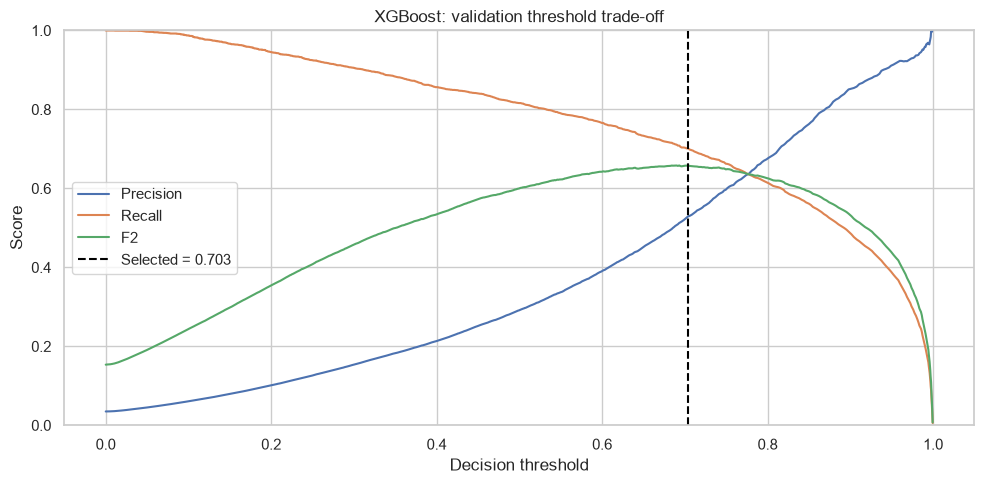

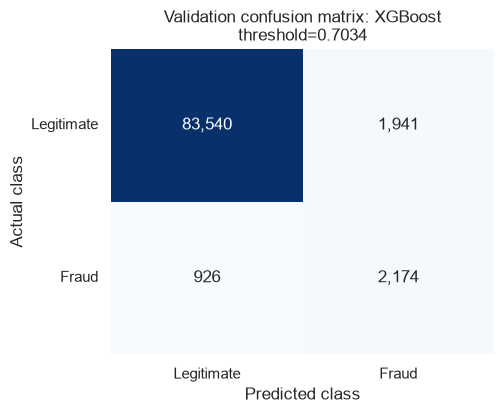

              precision    recall  f1-score   support

  Legitimate     0.9890    0.9773    0.9831     85481
       Fraud     0.5283    0.7013    0.6026      3100

    accuracy                         0.9676     88581
   macro avg     0.7587    0.8393    0.7929     88581
weighted avg     0.9729    0.9676    0.9698     88581



In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_table = thresholds.iloc[::max(1, len(thresholds) // 3000)]
ax.plot(plot_table["Threshold"], plot_table["Precision"], label="Precision")
ax.plot(plot_table["Threshold"], plot_table["Recall"], label="Recall")
ax.plot(plot_table["Threshold"], plot_table["F2"], label="F2")
ax.axvline(f2_threshold, color="black", linestyle="--", label=f"Selected = {f2_threshold:.3f}")
ax.set(xlabel="Decision threshold", ylabel="Score", title=f"{champion_name}: validation threshold trade-off", ylim=(0, 1))
ax.legend()
plt.tight_layout()
plt.show()

plot_confusion(
    y_validation, champion_validation_probability, f2_threshold,
    f"Validation confusion matrix: {champion_name}\nthreshold={f2_threshold:.4f}",
)
plt.show()

print(classification_report(
    y_validation,
    (champion_validation_probability >= f2_threshold).astype("int8"),
    target_names=["Legitimate", "Fraud"],
    digits=4,
))

### 7.2 Probability calibration diagnostic

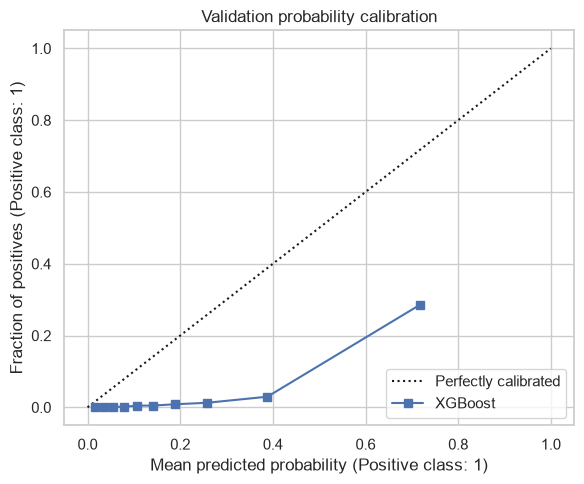

Calibration is diagnostic only. If probabilities will represent financial risk, calibrate the frozen model using training-only cross-validation before reevaluating validation data.


In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
CalibrationDisplay.from_predictions(
    y_validation, champion_validation_probability,
    n_bins=10, strategy="quantile", name=champion_name, ax=ax,
)
ax.set_title("Validation probability calibration")
plt.tight_layout()
plt.show()
print(
    "Calibration is diagnostic only. If probabilities will represent financial risk, "
    "calibrate the frozen model using training-only cross-validation before reevaluating validation data."
)

## 8. Optional Cross-Validated Hyperparameter Tuning

This section is disabled by default because tuning large models on more than 400,000 observations is expensive. When enabled, it uses stratified 3-fold cross-validation on the training split only and optimizes average precision. The validation set remains external to the search.

In [14]:
if RUN_TUNING:
    tuning_estimators = {
        "Logistic regression": (
            LogisticRegression(
                class_weight="balanced", solver="saga", max_iter=300,
                tol=1e-3, random_state=RANDOM_STATE,
            ),
            {"C": np.logspace(-2, 1, 8), "penalty": ["l1", "l2"]},
        ),
        "Decision tree": (
            DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
            {
                "max_depth": [5, 8, 12, 16, None],
                "min_samples_leaf": [10, 25, 50, 100, 250],
                "criterion": ["gini", "entropy"],
            },
        ),
        "Random forest": (
            RandomForestClassifier(
                class_weight="balanced_subsample", n_jobs=N_JOBS,
                random_state=RANDOM_STATE,
            ),
            {
                "n_estimators": [200, 350, 500],
                "max_depth": [10, 16, 24, None],
                "min_samples_leaf": [2, 5, 10, 25],
                "max_features": ["sqrt", 0.3, 0.5],
            },
        ),
    }

    if champion_name not in tuning_estimators:
        print(f"No tuning grid specified for {champion_name}; keep the fitted champion.")
    else:
        estimator, parameter_distributions = tuning_estimators[champion_name]
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
        search = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=parameter_distributions,
            n_iter=12 if not QUICK_RUN else 4,
            scoring="average_precision",
            cv=cv,
            n_jobs=N_JOBS,
            verbose=2,
            random_state=RANDOM_STATE,
            refit=True,
            return_train_score=True,
        )
        search.fit(X_fit, y_fit)
        tuned_probability = positive_class_probability(search.best_estimator_, X_validation)
        tuned_metrics = metric_row(y_validation, tuned_probability, threshold=0.50)
        print(f"Best CV AP: {search.best_score_:.4f}")
        print("Best parameters:", search.best_params_)
        display(pd.DataFrame([tuned_metrics]).style.format(precision=4))

        # Replace only if external validation AP improves.
        if tuned_metrics["Average precision"] > average_precision_score(
            y_validation, champion_validation_probability
        ):
            champion_model = search.best_estimator_
            champion_validation_probability = tuned_probability
            champion_name = f"{champion_name} (tuned)"
            thresholds = threshold_table(y_validation, champion_validation_probability)
            f2_threshold = float(thresholds.loc[thresholds["F2"].idxmax(), "Threshold"])
            print("The tuned model becomes the champion; threshold recomputed on validation.")
        else:
            print("Tuning did not improve validation AP; retaining the original champion.")
else:
    print("Tuning skipped. Set RUN_TUNING=True for the final experiment if resources allow.")

No tuning grid specified for XGBoost; keep the fitted champion.


## 9. Freeze the Decision and Evaluate the Test Set Once

At this point the model family, fitted model, and decision threshold are frozen. The test set is now loaded for the first and only time. It must not be used to revise the model or threshold.

In [15]:
X_test = pd.read_parquet(PROCESSED_DATA_PATH / "X_test.parquet")
y_test = pd.read_parquet(PROCESSED_DATA_PATH / "y_test.parquet")["isFraud"].astype("int8")
id_test = pd.read_parquet(PROCESSED_DATA_PATH / "id_test.parquet")["TransactionID"]

assert X_test.columns.equals(X_train.columns)
assert len(X_test) == len(y_test) == len(id_test)
assert not id_test.isin(set(id_train)).any()
assert not id_test.isin(set(id_validation)).any()

test_probability = positive_class_probability(champion_model, X_test)
test_metrics = metric_row(y_test, test_probability, threshold=f2_threshold)

final_comparison = pd.DataFrame([
    {"Split": "Validation", **metric_row(
        y_validation, champion_validation_probability, threshold=f2_threshold
    )},
    {"Split": "Test", **test_metrics},
]).set_index("Split")

display(final_comparison[[
    "Threshold", "Average precision", "ROC-AUC", "Balanced accuracy",
    "Precision", "Recall", "F1", "F2", "Alert rate", "TP", "FP", "FN", "TN",
]].style.format({
    "Threshold": "{:.4f}", "Average precision": "{:.4f}", "ROC-AUC": "{:.4f}",
    "Balanced accuracy": "{:.4f}", "Precision": "{:.4f}", "Recall": "{:.4f}",
    "F1": "{:.4f}", "F2": "{:.4f}", "Alert rate": "{:.2%}",
}))

,Threshold,Average precision,ROC-AUC,Balanced accuracy,Precision,Recall,F1,F2,Alert rate,TP,FP,FN,TN
Split,,,,,,,,,,,,,
Validation,0.7034,0.6851,0.9465,0.8393,0.5283,0.7013,0.6026,0.6582,4.65%,2174,1941,926,83540
Test,0.7034,0.7119,0.9511,0.8474,0.5512,0.7160,0.6229,0.6756,4.54%,2219,1807,880,83675


### 9.1 Final test confusion matrix

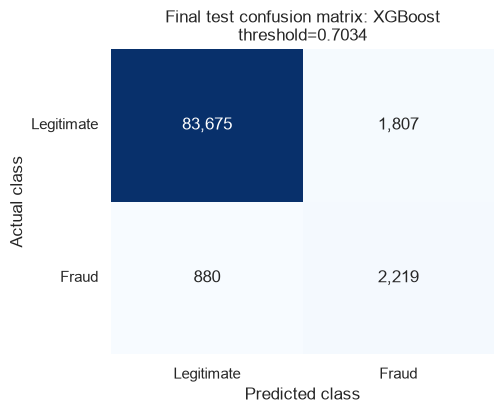

              precision    recall  f1-score   support

  Legitimate     0.9896    0.9789    0.9842     85482
       Fraud     0.5512    0.7160    0.6229      3099

    accuracy                         0.9697     88581
   macro avg     0.7704    0.8474    0.8035     88581
weighted avg     0.9743    0.9697    0.9716     88581



In [16]:
plot_confusion(
    y_test, test_probability, f2_threshold,
    f"Final test confusion matrix: {champion_name}\nthreshold={f2_threshold:.4f}",
)
plt.show()

print(classification_report(
    y_test,
    (test_probability >= f2_threshold).astype("int8"),
    target_names=["Legitimate", "Fraud"],
    digits=4,
))

## 10. Persist the Champion and Investigation Outputs

In [17]:
safe_model_name = (
    champion_name.lower().replace(" ", "_").replace("(", "").replace(")", "")
)
model_file = MODEL_PATH / f"{safe_model_name}.joblib"
metadata_file = MODEL_PATH / f"{safe_model_name}_metadata.json"

joblib.dump(champion_model, model_file)

metadata = {
    "model_name": champion_name,
    "decision_threshold": f2_threshold,
    "threshold_rule": "maximum validation F2",
    "primary_selection_metric": "validation average precision",
    "random_state": RANDOM_STATE,
    "quick_run": QUICK_RUN,
    "training_rows_used": len(X_fit),
    "feature_count": X_fit.shape[1],
    "test_metrics": {key: float(value) if isinstance(value, (float, np.floating)) else int(value)
                     for key, value in test_metrics.items()},
}
metadata_file.write_text(json.dumps(metadata, indent=2))

validation_predictions = pd.DataFrame({
    "TransactionID": id_validation.to_numpy(),
    "isFraud": y_validation.to_numpy(),
    "fraud_probability": champion_validation_probability,
    "predicted_fraud": (champion_validation_probability >= f2_threshold).astype("int8"),
    "split": "validation",
})
test_predictions = pd.DataFrame({
    "TransactionID": id_test.to_numpy(),
    "isFraud": y_test.to_numpy(),
    "fraud_probability": test_probability,
    "predicted_fraud": (test_probability >= f2_threshold).astype("int8"),
    "split": "test",
})
predictions = pd.concat([validation_predictions, test_predictions], ignore_index=True)
predictions.to_parquet(RESULTS_PATH / "champion_predictions.parquet", index=False)

validation_results.reset_index().to_csv(
    RESULTS_PATH / "validation_model_comparison.csv", index=False
)
final_comparison.reset_index().to_csv(
    RESULTS_PATH / "champion_validation_test_metrics.csv", index=False
)

print(f"Saved model: {model_file}")
print(f"Saved metadata: {metadata_file}")
print(f"Saved predictions and metrics: {RESULTS_PATH}")

Saved model: /Users/hshazel/Projects/explainable-fraud-investigation-platform/models/trained/xgboost.joblib
Saved metadata: /Users/hshazel/Projects/explainable-fraud-investigation-platform/models/trained/xgboost_metadata.json
Saved predictions and metrics: /Users/hshazel/Projects/explainable-fraud-investigation-platform/results/model_comparison


## 11. Model Development Summary and Next Steps

This notebook compares a no-skill baseline, a parametric linear model, non-parametric tree models, ensemble methods, and optional neural-network and XGBoost benchmarks. Models are ranked using validation average precision, then a recall-oriented F2 threshold is selected using validation data only. The frozen model and threshold are evaluated once on the untouched test set.

### Reporting checklist

- Report the class prevalence and explain why accuracy is misleading.
- Compare average precision and ROC-AUC, not either metric in isolation.
- Discuss the false-negative/false-positive trade-off in business terms.
- Report both the default and selected thresholds.
- State whether `QUICK_RUN`, optional models, and tuning were enabled.
- Treat the final test result as confirmatory, not another tuning signal.

### Next notebook

`04_Model_Explainability_Fraud_Investigation.ipynb` will use the saved champion, threshold, and transaction-level predictions to provide:

- Global feature importance and SHAP-based explanations
- Local explanations for true positives, false positives, and false negatives
- Investigator-oriented transaction case summaries
- Error analysis by transaction amount, product type, device, geography, and time
- Optional natural-language investigation narratives grounded in model evidence